In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [18]:

def calculate_confidence_intervals(values, confidence=0.95):
    """Calculate mean and confidence intervals"""
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    
    mean_val = np.mean(values)
    
    if len(values) == 1:
        return mean_val, mean_val, mean_val
    
    alpha = 1 - confidence
    dof = len(values) - 1
    t_critical = stats.t.ppf(1 - alpha/2, dof)
    std_err = stats.sem(values)
    margin_error = t_critical * std_err
    
    ci_lower = mean_val - margin_error
    ci_upper = mean_val + margin_error
    
    return mean_val, ci_lower, ci_upper

def create_focused_comparison_table(base_pattern="output_0905_stratifier_high_stage_seed*/pipeline_results.csv",
                                  cutoff_value=50000):
    """
    Create focused table comparing models in highest 2 risk bins for AUC and recall
    """
    
    # Load all results
    result_files = glob.glob(base_pattern)
    if not result_files:
        raise FileNotFoundError(f"No result files found matching pattern: {base_pattern}")
    
    all_results = []
    for file_path in result_files:
        seed = file_path.split('seed')[1].split('/')[0] if 'seed' in file_path else 'unknown'
        df = pd.read_csv(file_path)
        df['seed'] = seed
        all_results.append(df)
    
    combined_df = pd.concat(all_results, ignore_index=True)
    
    # Filter for the specific cutoff and exclude Overall bin
    df = combined_df[
        (combined_df['cutoff_value'] == cutoff_value) & 
        (combined_df['bin'] != 'Overall')
    ].copy()
    
    # Get the highest 2 risk bins
    unique_bins = sorted(df['bin'].unique())#, key=extract_lower_bound)
    highest_2_bins = unique_bins[-2:]  # Get last 2 (highest risk)
    
    print(f"Analyzing highest 2 risk bins: {highest_2_bins}")
    print(f"Using data from {df['seed'].nunique()} seeds")
    print(f"Cutoff: ${cutoff_value:,}")
    
    # Filter to highest 2 bins only
    df_filtered = df[df['bin'].isin(highest_2_bins)].copy()
    
    # Prepare results table
    results = []
    
    models = sorted(df_filtered['model_name'].unique())
    dataset_labels = sorted(df_filtered['dataset_name'].unique())
    metrics = ['auc', 'recall']
    
    for model in models:
        for dataset in dataset_labels:
            for metric in metrics:
                for bin_name in highest_2_bins:
                    # Get data for this combination
                    subset = df_filtered[
                        (df_filtered['model_name'] == model) &
                        (df_filtered['dataset_name'] == dataset) &
                        (df_filtered['bin'] == bin_name)
                    ]
                    
                    if not subset.empty and metric in subset.columns:
                        values = subset[metric].dropna().values
                        mean_val, ci_lower, ci_upper = calculate_confidence_intervals(values)
                        
                        results.append({
                            'Model': model,
                            'Matching': dataset,
                            'Risk_Bin': bin_name,
                            'Metric': metric.upper(),
                            'Mean': mean_val,
                            'CI_Lower': ci_lower,
                            'CI_Upper': ci_upper,
                            'N_Seeds': len(values),
                            'Std': np.std(values) if len(values) > 1 else 0
                        })
    
    results_df = pd.DataFrame(results)
    
    # Create the focused table
    print(f"\n{'='*80}")
    print(f"MODEL COMPARISON: HIGHEST 2 RISK BINS - AUC & RECALL")
    print(f"Cutoff: ${cutoff_value:,} | Bins: {highest_2_bins}")
    print(f"Confidence Intervals: 95% | Seeds: {df['seed'].nunique()}")
    print(f"{'='*80}")
    
    # Format the table for display
    for metric in ['AUC', 'RECALL']:
        print(f"\n{metric} PERFORMANCE:")
        print("-" * 60)
        
        metric_data = results_df[results_df['Metric'] == metric]
        
        # Create pivot table structure
        for bin_name in highest_2_bins:
            print(f"\nRisk Bin: {bin_name}")
            print(f"{'Model':<15} {'Before Matching':<25} {'After Matching':<25}")
            print("-" * 65)
            
            bin_data = metric_data[metric_data['Risk_Bin'] == bin_name]
            
            for model in models:
                model_data = bin_data[bin_data['Model'] == model]
                
                before_data = model_data[model_data['Matching'].str.contains('Before', na=False)]
                after_data = model_data[model_data['Matching'].str.contains('After', na=False)]
                
                before_str = ""
                if not before_data.empty:
                    row = before_data.iloc[0]
                    before_str = f"{row['Mean']:.3f} [{row['CI_Lower']:.3f}, {row['CI_Upper']:.3f}]"
                
                after_str = ""
                if not after_data.empty:
                    row = after_data.iloc[0]
                    after_str = f"{row['Mean']:.3f} [{row['CI_Lower']:.3f}, {row['CI_Upper']:.3f}]"
                
                print(f"{model:<15} {before_str:<25} {after_str:<25}")
    
    return results_df

def calculate_matching_impact(results_df):
    """Calculate the impact of matching on performance"""
    
    print(f"\n{'='*60}")
    print("MATCHING IMPACT ANALYSIS")
    print(f"{'='*60}")
    
    models = results_df['Model'].unique()
    bins = results_df['Risk_Bin'].unique()
    metrics = results_df['Metric'].unique()
    
    for metric in metrics:
        print(f"\n{metric} - IMPROVEMENT FROM MATCHING:")
        print("-" * 50)
        print(f"{'Model':<15} {'Bin':<12} {'Before':<8} {'After':<8} {'Change':<10} {'% Change':<10}")
        print("-" * 70)
        
        metric_data = results_df[results_df['Metric'] == metric]
        
        for model in models:
            for bin_name in bins:
                model_bin_data = metric_data[
                    (metric_data['Model'] == model) & 
                    (metric_data['Risk_Bin'] == bin_name)
                ]
                
                before = model_bin_data[model_bin_data['Matching'].str.contains('Before', na=False)]
                after = model_bin_data[model_bin_data['Matching'].str.contains('After', na=False)]
                
                if not before.empty and not after.empty:
                    before_val = before.iloc[0]['Mean']
                    after_val = after.iloc[0]['Mean']
                    change = after_val - before_val
                    pct_change = (change / before_val * 100) if before_val != 0 else 0
                    
                    print(f"{model:<15} {bin_name:<12} {before_val:.3f}   {after_val:.3f}   {change:+.3f}     {pct_change:+.1f}%")

def statistical_significance_tests(results_df):
    """Test statistical significance of matching impact"""
    
    print(f"\n{'='*60}")
    print("STATISTICAL SIGNIFICANCE OF MATCHING")
    print(f"{'='*60}")
    
    # This would require the raw data from each seed to do proper paired t-tests
    # For now, show confidence interval overlaps
    
    models = results_df['Model'].unique()
    bins = results_df['Risk_Bin'].unique()
    metrics = results_df['Metric'].unique()
    
    for metric in metrics:
        print(f"\n{metric} - CONFIDENCE INTERVAL OVERLAPS:")
        print("-" * 50)
        
        metric_data = results_df[results_df['Metric'] == metric]
        
        for model in models:
            for bin_name in bins:
                model_bin_data = metric_data[
                    (metric_data['Model'] == model) & 
                    (metric_data['Risk_Bin'] == bin_name)
                ]
                
                before = model_bin_data[model_bin_data['Matching'].str.contains('Before', na=False)]
                after = model_bin_data[model_bin_data['Matching'].str.contains('After', na=False)]
                
                if not before.empty and not after.empty:
                    before_ci = (before.iloc[0]['CI_Lower'], before.iloc[0]['CI_Upper'])
                    after_ci = (after.iloc[0]['CI_Lower'], after.iloc[0]['CI_Upper'])
                    
                    # Check if confidence intervals overlap
                    overlap = not (before_ci[1] < after_ci[0] or after_ci[1] < before_ci[0])
                    significance = "Not significant (CIs overlap)" if overlap else "Likely significant (CIs don't overlap)"
                    
                    print(f"{model} - {bin_name}: {significance}")

# Main function
def run_focused_analysis(base_pattern="output_stratifier_high_stage_seed*/pipeline_results.csv", 
                        cutoff_value=50000):
    """
    Run the complete focused analysis
    """
    # Create the main comparison table
    results_df = create_focused_comparison_table(base_pattern, cutoff_value)
    
    # Calculate matching impact
    calculate_matching_impact(results_df)
    
    # Statistical significance
    statistical_significance_tests(results_df)
    
    return results_df

# Usage
base_pattern="output_0911/output_0911_stratifier_high_stage_seed*/pipeline_results.csv"
if __name__ == "__main__":
    results = run_focused_analysis(base_pattern="output_0911/output_0911_stratifier_high_stage_seed*/pipeline_results.csv")
    print("\nFocused analysis complete!")

Analyzing highest 2 risk bins: ['6', '7']
Using data from 20 seeds
Cutoff: $50,000

MODEL COMPARISON: HIGHEST 2 RISK BINS - AUC & RECALL
Cutoff: $50,000 | Bins: ['6', '7']
Confidence Intervals: 95% | Seeds: 20

AUC PERFORMANCE:
------------------------------------------------------------

Risk Bin: 6
Model           Before Matching           After Matching           
-----------------------------------------------------------------
Gradient Boosting 0.723 [0.713, 0.733]      0.701 [0.689, 0.713]     
Logistic        0.727 [0.718, 0.736]      0.728 [0.720, 0.737]     
Random Forest   0.672 [0.663, 0.682]      0.652 [0.642, 0.662]     
oct             0.629 [0.607, 0.651]      0.611 [0.592, 0.630]     

Risk Bin: 7
Model           Before Matching           After Matching           
-----------------------------------------------------------------
Gradient Boosting 0.756 [0.745, 0.767]      0.747 [0.735, 0.759]     
Logistic        0.761 [0.751, 0.772]      0.765 [0.756, 0.775]     
Rando

output_0911/output_0911_stratifier_high_stage_seed*/pipeline_results.csv
HIGHEST RISK BIN PERFORMANCE ACROSS CUTOFFS
unique_bins:  ['0', '1', '2', '3', '4', '5', '6', '7']
Analyzing highest risk bin: ['6', '7']
Using data from 20 seeds


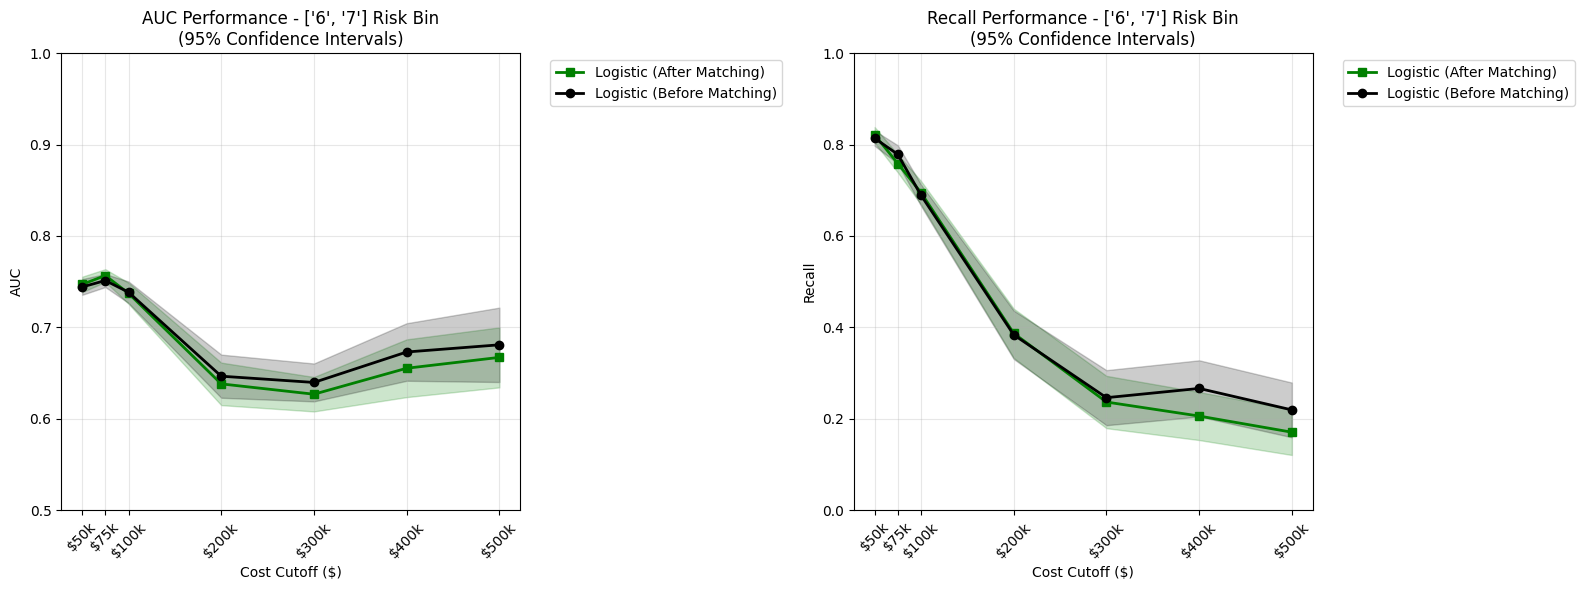


SUMMARY: ['6', '7'] RISK BIN PERFORMANCE ACROSS CUTOFFS

AUC Performance Summary:
--------------------------------------------------
Model           Matching Mean     95% CI               N    
------------------------------------------------------------
Logistic        After    0.690   [0.680, 0.700]       280  
Logistic        Before   0.696   [0.686, 0.706]       280  

RECALL Performance Summary:
--------------------------------------------------
Model           Matching Mean     95% CI               N    
------------------------------------------------------------
Logistic        After    0.468   [0.433, 0.502]       280  
Logistic        Before   0.485   [0.452, 0.519]       280  

STATISTICAL MODEL COMPARISON - ['6', '7'] RISK BIN

BEFORE MATCHING:
----------------------------------------

AUC Rankings (Mean ± 95% CI):
1. Gradient Boosting: 0.701 ± 0.009 [0.691, 0.710]
2. Logistic       : 0.696 ± 0.010 [0.686, 0.706]
3. Random Forest  : 0.687 ± 0.007 [0.681, 0.694]
4. oct     

In [25]:

def extract_lower_bound(bin_str):
    """Extract the lower bound from a bin string for sorting"""
    import re
    if pd.isna(bin_str) or bin_str == 'Overall':
        return -1
    match = re.search(r'(\d+\.\d+)-', str(bin_str))
    return float(match.group(1)) if match else 0.0

def calculate_confidence_intervals(values, confidence=0.95):
    """Calculate mean and confidence intervals"""
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    
    mean_val = np.mean(values)
    
    if len(values) == 1:
        return mean_val, mean_val, mean_val
    
    alpha = 1 - confidence
    dof = len(values) - 1
    t_critical = stats.t.ppf(1 - alpha/2, dof)
    std_err = stats.sem(values)
    margin_error = t_critical * std_err
    
    ci_lower = mean_val - margin_error
    ci_upper = mean_val + margin_error
    
    return mean_val, ci_lower, ci_upper

def plot_highest_risk_performance_across_cutoffs(model_prefix="Gradient",base_pattern="output_0905_stratifier_high_stage_seed*/pipeline_results.csv"):
    """
    Plot performance across different cutoffs for the highest risk bin only
    """
    
    # Load all results
    result_files = glob.glob(base_pattern)
    if not result_files:
        raise FileNotFoundError(f"No result files found matching pattern: {base_pattern}")
    
    all_results = []
    for file_path in result_files:
        seed = file_path.split('seed')[1].split('/')[0] if 'seed' in file_path else 'unknown'
        df = pd.read_csv(file_path)
        df['seed'] = seed
        all_results.append(df)
    
    combined_df = pd.concat(all_results, ignore_index=True)
    
    # Get the highest risk bin
    df_no_overall = combined_df[combined_df['bin'] != 'Overall'].copy()
    unique_bins = sorted(df_no_overall['bin'].unique())
    print("unique_bins: ",unique_bins)
    highest_risk_bin = unique_bins[-2:]  # Get the highest risk bin
    
    print(f"Analyzing highest risk bin: {highest_risk_bin}")
    print(f"Using data from {combined_df['seed'].nunique()} seeds")
    
    # Filter to highest risk bin only
    df_filtered = combined_df[combined_df['bin'].isin(highest_risk_bin)].copy()
    
    # Get unique values
    cutoffs = sorted(df_filtered['cutoff_value'].unique())
    models = [model for model in df_filtered['model_name'].unique() if model.startswith(model_prefix)]
    #models = sorted(df_filtered['model_name'].unique())
    dataset_labels = sorted(df_filtered['dataset_name'].unique())
    
    # Create the plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    colors = {'Before Matching': 'black', 'After Matching': 'green'}
    markers = {'Before Matching': 'o', 'After Matching': 's'}
    
    metrics = ['auc', 'recall']
    metric_titles = ['AUC', 'Recall']
    
    for i, (metric, title) in enumerate(zip(metrics, metric_titles)):
        ax = axes[i]
        
        for model in models:
            for dataset in dataset_labels:
                # Determine matching status
                if "Before" in dataset:
                    matching_status = "Before Matching"
                elif "After" in dataset:
                    matching_status = "After Matching"
                else:
                    matching_status = "Before Matching"
                
                # Collect data for this model/dataset combination across cutoffs
                x_values = []
                mean_values = []
                ci_lower_values = []
                ci_upper_values = []
                
                for cutoff in cutoffs:
                    subset = df_filtered[
                        (df_filtered['model_name'] == model) &
                        (df_filtered['dataset_name'] == dataset) &
                        (df_filtered['cutoff_value'] == cutoff)
                    ]
                    
                    if not subset.empty and metric in subset.columns:
                        values = subset[metric].dropna().values
                        
                        if len(values) > 0:
                            mean_val, ci_lower, ci_upper = calculate_confidence_intervals(values)
                            
                            if not np.isnan(mean_val):
                                x_values.append(cutoff)
                                mean_values.append(mean_val)
                                ci_lower_values.append(ci_lower)
                                ci_upper_values.append(ci_upper)
                
                # Plot if we have data
                if len(mean_values) > 0:
                    color = colors[matching_status]
                    marker = markers[matching_status]
                    
                    # Create label
                    label = f"{model} ({matching_status})"
                    
                    # Plot mean line
                    ax.plot(x_values, mean_values, 
                           color=color, marker=marker,
                           linewidth=2, markersize=6, label=label)
                    
                    # Plot confidence interval
                    ax.fill_between(x_values, ci_lower_values, ci_upper_values,
                                   color=color, alpha=0.2)
        
        # Formatting
        ax.set_xlabel('Cost Cutoff ($)')
        ax.set_ylabel(f'{title}')
        ax.set_title(f'{title} Performance - {highest_risk_bin} Risk Bin\n(95% Confidence Intervals)')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True, alpha=0.3)
        
        # Format x-axis labels
        cutoff_labels = [f"${c//1000}k" for c in cutoffs]
        ax.set_xticks(cutoffs)
        ax.set_xticklabels(cutoff_labels, rotation=45)
        
        # Set y-axis to reasonable range
        if metric == 'auc':
            ax.set_ylim(0.5, 1.0)
        else:  # recall
            ax.set_ylim(0.0, 1.0)
    
    plt.tight_layout()
    plt.savefig(f'highest_risk_bin_performance_across_cutoffs.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*80}")
    print(f"SUMMARY: {highest_risk_bin} RISK BIN PERFORMANCE ACROSS CUTOFFS")
    print(f"{'='*80}")
    
    for metric in metrics:
        print(f"\n{metric.upper()} Performance Summary:")
        print("-" * 50)
        
        # Calculate overall performance across all cutoffs for each model/matching combination
        summary_data = []
        
        for model in models:
            for dataset in dataset_labels:
                subset = df_filtered[
                    (df_filtered['model_name'] == model) &
                    (df_filtered['dataset_name'] == dataset)
                ]
                
                if not subset.empty and metric in subset.columns:
                    values = subset[metric].dropna().values
                    
                    if len(values) > 0:
                        mean_val, ci_lower, ci_upper = calculate_confidence_intervals(values)
                        
                        matching_status = "Before" if "Before" in dataset else "After"
                        
                        summary_data.append({
                            'Model': model,
                            'Matching': matching_status,
                            'Mean': mean_val,
                            'CI_Lower': ci_lower,
                            'CI_Upper': ci_upper,
                            'N_Observations': len(values)
                        })
        
        # Display summary table
        summary_df = pd.DataFrame(summary_data)
        if not summary_df.empty:
            print(f"{'Model':<15} {'Matching':<8} {'Mean':<8} {'95% CI':<20} {'N':<5}")
            print("-" * 60)
            
            for _, row in summary_df.iterrows():
                ci_str = f"[{row['CI_Lower']:.3f}, {row['CI_Upper']:.3f}]"
                print(f"{row['Model']:<15} {row['Matching']:<8} {row['Mean']:.3f}   {ci_str:<20} {row['N_Observations']:<5}")

def compare_models_statistically(base_pattern="output_0905_stratifier_high_stage_seed*/pipeline_results.csv"):
    """
    Statistical comparison showing which model performs best with confidence
    """
    
    # Load data (same as above)
    result_files = glob.glob(base_pattern)
    all_results = []
    for file_path in result_files:
        seed = file_path.split('seed')[1].split('/')[0] if 'seed' in file_path else 'unknown'
        df = pd.read_csv(file_path)
        df['seed'] = seed
        all_results.append(df)
    
    combined_df = pd.concat(all_results, ignore_index=True)
    
    # Get highest risk bin
    df_no_overall = combined_df[combined_df['bin'] != 'Overall'].copy()
    unique_bins = sorted(df_no_overall['bin'].unique()) #, key=extract_lower_bound)
    highest_risk_bin = unique_bins[-2:] 
    
    df_filtered = combined_df[combined_df['bin'].isin(highest_risk_bin)].copy()
    
    print(f"\n{'='*80}")
    print(f"STATISTICAL MODEL COMPARISON - {highest_risk_bin} RISK BIN")
    print(f"{'='*80}")
    
    for dataset in df_filtered['dataset_name'].unique():
        matching_status = "Before Matching" if "Before" in dataset else "After Matching"
        print(f"\n{matching_status.upper()}:")
        print("-" * 40)
        
        dataset_data = df_filtered[df_filtered['dataset_name'] == dataset]
        
        for metric in ['auc', 'recall']:
            print(f"\n{metric.upper()} Rankings (Mean ± 95% CI):")
            
            model_performances = []
            models = dataset_data['model_name'].unique()
            
            for model in models:
                model_data = dataset_data[dataset_data['model_name'] == model]
                
                if not model_data.empty and metric in model_data.columns:
                    values = model_data[metric].dropna().values
                    
                    if len(values) > 0:
                        mean_val, ci_lower, ci_upper = calculate_confidence_intervals(values)
                        
                        model_performances.append({
                            'Model': model,
                            'Mean': mean_val,
                            'CI_Lower': ci_lower,
                            'CI_Upper': ci_upper,
                            'CI_Width': ci_upper - ci_lower
                        })
            
            # Sort by performance
            model_performances.sort(key=lambda x: x['Mean'], reverse=True)
            
            for i, perf in enumerate(model_performances, 1):
                ci_width = perf['CI_Width']
                print(f"{i}. {perf['Model']:<15}: {perf['Mean']:.3f} ± {ci_width/2:.3f} "
                      f"[{perf['CI_Lower']:.3f}, {perf['CI_Upper']:.3f}]")

# Main function to run everything
def run_cutoff_analysis(base_pattern="output_0905_stratifier_high_stage_seed*/pipeline_results.csv"):
    """
    Run the complete cutoff analysis
    """
    print("HIGHEST RISK BIN PERFORMANCE ACROSS CUTOFFS")
    print("=" * 50)
    model_prefix = "Logistic"
    # Create the main plot
    plot_highest_risk_performance_across_cutoffs(model_prefix,base_pattern)
    
    # Statistical comparison
    compare_models_statistically(base_pattern)
    
    print("\nAnalysis complete!")
    print("- Performance plot saved as 'highest_risk_bin_performance_across_cutoffs.png'")
    print("- Check the plot to easily see which models have tighter confidence intervals")
    print("- Models with smaller confidence bands are more consistent across seeds")

# Usage
if __name__ == "__main__":
    print(base_pattern)
    run_cutoff_analysis(base_pattern=base_pattern)